# Exercise 10 - Classification with ANN

The goal of this exercise is to predict whether a customer defaults on his /her credit card.
The data is taken from https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients

The output variable is a binary variable for default payment (Yes = 1, No = 0)

The input variables are the following:

1. Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
2. Gender (1 = male; 2 = female).
3. Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
4. Marital status (1 = married; 2 = single; 3 = others).
5. Age (year).
6. the repayment status in September, 2005
7. the repayment status in August, 2005
8. the repayment status in July, 2005
9. the repayment status in June, 2005
10. the repayment status in May, 2005
11. the repayment status in April, 2005
12. amount of bill statement in September, 2005
13. amount of bill statement in August, 2005
14. amount of bill statement in July, 2005
15. amount of bill statement in June, 2005
16. amount of bill statement in May, 2005
17. amount of bill statement in April, 2005
18. amount paid in September, 2005
19. amount paid in August, 2005
20. amount paid in July, 2005
21. amount paid in June, 2005
22. amount paid in May, 2005
23. amount paid in April, 2005.

The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.

**Note:** If you apply a linear model for classification, you may need to transform *gender*, *education*, *marital status*, and *repayment status* into dummy variables.
If you use a ANN, this may not be necessary. However, you may investigate whether the performance is different if categorical variables are described by dummy variables. 


In [2]:
import pandas as pd

# Load the data
df = pd.read_csv("Exercise_10_Data.csv", delimiter=';')


In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
df.Default.value_counts()/len(df.Default)

Default
0    0.7788
1    0.2212
Name: count, dtype: float64

In [5]:
# For selecting variable you look at the correlations
df.corr()['Default']

ID          -0.013952
LIMIT_BAL   -0.153520
SEX         -0.039961
EDUCATION    0.028006
MARRIAGE    -0.024339
AGE          0.013890
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
Default      1.000000
Name: Default, dtype: float64

In [6]:
# Let us select some (arbituary) variables
X = df[['MARRIAGE', 'AGE', 'PAY_0', 'PAY_2']]
y = df['Default']

In [7]:
X

,MARRIAGE,AGE,PAY_0,PAY_2
0,1,24,2,2
1,2,26,-1,2
2,2,34,0,0
3,1,37,0,0
4,1,57,-1,0
...,...,...,...,...
29995,1,39,0,0
29996,2,43,-1,-1
29997,2,37,4,3
29998,1,41,1,-1


In [8]:
y

0        1
1        1
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    1
29998    1
29999    1
Name: Default, Length: 30000, dtype: int64

In [9]:
# Split the data
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, shuffle = True)

In [11]:
y_train = pd.DataFrame(y_train)
y_test = pd.DataFrame(y_test)

## ANN model

In [12]:
n_features = X.shape[1]
n_classes = len(y.unique())

In [13]:
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

In [14]:
model = Sequential()
model.add(Dense(10, input_dim = n_features, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(n_classes, activation = 'softmax'))

In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                50        
                                                                 
 dense_1 (Dense)             (None, 10)                110       
                                                                 
 dense_2 (Dense)             (None, 2)                 22        
                                                                 
Total params: 182 (728.00 Byte)
Trainable params: 182 (728.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [16]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam')

In [33]:
early_stop = EarlyStopping(monitor = 'loss', patience = 5, verbose = 1)

In [36]:
history = model.fit(X_train, y_train, epochs = 20, batch_size = 10, callbacks = [early_stop])

Epoch 1/20
2400/2400 [==============================] - 6s 3ms/step - loss: 0.4479
Epoch 2/20
2400/2400 [==============================] - 5s 2ms/step - loss: 0.4476
Epoch 3/20
2400/2400 [==============================] - 6s 2ms/step - loss: 0.4476
Epoch 4/20
2400/2400 [==============================] - 8s 4ms/step - loss: 0.4474
Epoch 5/20
2400/2400 [==============================] - 6s 3ms/step - loss: 0.4477
Epoch 6/20
2400/2400 [==============================] - 6s 2ms/step - loss: 0.4475
Epoch 7/20
2400/2400 [==============================] - 5s 2ms/step - loss: 0.4475
Epoch 8/20
2400/2400 [==============================] - 5s 2ms/step - loss: 0.4478
Epoch 9/20
2400/2400 [==============================] - 6s 3ms/step - loss: 0.4477
Epoch 9: early stopping


## History

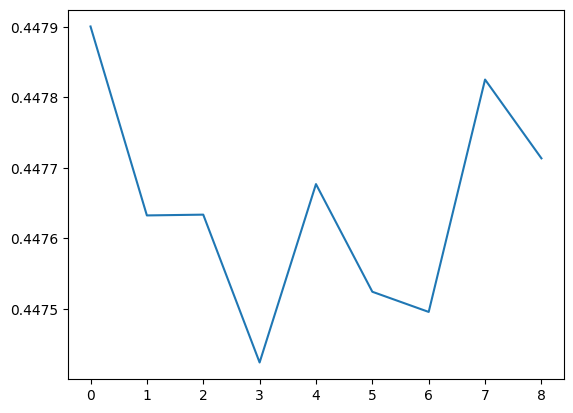

In [37]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.show()